# Environmental Sensor Monitoring & Anomaly Detection

## Project Overview

This project analyzes real-world environmental sensor observations using Python, statistical analysis, and unsupervised machine learning.

The main objective is to identify unusual environmental conditions using two complementary approaches:

1. **Interquartile Range (IQR)** for detecting extreme temperature observations.
2. **Isolation Forest** for detecting multivariate anomalies across temperature, humidity, carbon monoxide, and nitrogen dioxide.

### Dataset

**UCI Air Quality Dataset**

### Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab

### Key Results

- **9,357** valid timestamped observations
- **3** temperature anomalies detected using IQR
- **70** multivariate anomalies detected using Isolation Forest
- **73** total unique anomaly records
- **0.78%** of observations were flagged as anomalous

### Environmental Variables

- Temperature (T)
- Relative Humidity (RH)
- Absolute Humidity (AH)
- Carbon Monoxide (CO)
- Nitrogen Dioxide (NO₂)

> **Note:** The detected anomalies represent statistical patterns in the dataset. They do not by themselves establish that an observation corresponds to a confirmed environmental event or that one variable caused another.


## Methodology

### 1. Data Loading

The UCI Air Quality dataset was loaded into a Pandas DataFrame directly from the dataset archive.

### 2. Data Cleaning

The following preprocessing steps were performed:

- Removed completely empty columns.
- Converted the dataset's `-200` missing-value indicator to `NaN`.
- Combined the `Date` and `Time` columns into a single `Timestamp`.
- Removed observations with invalid timestamps.
- Sorted observations chronologically.

### 3. Exploratory Analysis

Temperature was analyzed over time and its distribution was examined to understand the environmental conditions represented in the dataset.

### 4. Statistical Anomaly Detection

The Interquartile Range (IQR) method was applied to temperature:

\[
IQR = Q3 - Q1
\]

Observations outside:

\[
Q1 - 1.5(IQR)
\]

and

\[
Q3 + 1.5(IQR)
\]

were classified as temperature anomalies.

### 5. Multivariate Machine Learning

Isolation Forest was applied to:

- Temperature
- Relative Humidity
- Absolute Humidity
- CO
- NO₂

The selected variables were standardized before model fitting.

The model was configured with a contamination parameter of 0.01.

### 6. Comparative Analysis

Normal observations and ML-anomalous observations were compared using:

- Mean values
- Percentage differences
- Standardized means
- CO vs NO₂ relationships

### 7. Data Quality Assessment

Missing observations and duplicate timestamps were checked before finalizing the project dataset.

## 1. Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
import pandas as pd
import zipfile
import requests
import io

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print(z.namelist())

['AirQualityUCI.csv', 'AirQualityUCI.xlsx']


In [6]:
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open("AirQualityUCI.csv") as f:
        df = pd.read_csv(
            f,
            sep=";",
            decimal=",",
            encoding="latin1"
        )

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [7]:
df.shape

(9471, 17)

In [8]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


In [10]:
df.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


In [11]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


In [12]:
df_raw = df.copy()

print("Original dataset:", df_raw.shape)

Original dataset: (9471, 17)


In [13]:
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"])

print(df.shape)

(9471, 15)


In [14]:
df = df.replace(-200, np.nan)

In [15]:
df.isnull().sum()

,0
Date,114
Time,114
CO(GT),1797
PT08.S1(CO),480
NMHC(GT),8557
C6H6(GT),480
PT08.S2(NMHC),480
NOx(GT),1753
PT08.S3(NOx),480
NO2(GT),1756


## 2. Data Cleaning and Preprocessing

In [16]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})

missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
NMHC(GT),8557,90.349488
CO(GT),1797,18.973709
NO2(GT),1756,18.540809
NOx(GT),1753,18.509133
PT08.S2(NMHC),480,5.068103
C6H6(GT),480,5.068103
PT08.S1(CO),480,5.068103
PT08.S5(O3),480,5.068103
T,480,5.068103
PT08.S3(NOx),480,5.068103


In [20]:
df["Timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

df[["Date", "Time", "Timestamp"]].head()

/tmp/ipykernel_1089/3188763249.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Timestamp"] = pd.to_datetime(


,Date,Time,Timestamp
0,10/03/2004,18.00.00,NaT
1,10/03/2004,19.00.00,NaT
2,10/03/2004,20.00.00,NaT
3,10/03/2004,21.00.00,NaT
4,10/03/2004,22.00.00,NaT


In [21]:
print(df["Timestamp"].dtype)

datetime64[ns]


In [22]:
print("Invalid timestamps:", df["Timestamp"].isna().sum())

Invalid timestamps: 9471


In [23]:
df = df.dropna(subset=["Timestamp"])

print("Dataset after removing invalid timestamps:", df.shape)

Dataset after removing invalid timestamps: (0, 16)


In [24]:
df = df.sort_values("Timestamp").reset_index(drop=True)

In [25]:
df[["Timestamp", "T", "RH", "CO(GT)", "NO2(GT)"]].head(10)

,Timestamp,T,RH,CO(GT),NO2(GT)


## 3. Exploratory Data Analysis

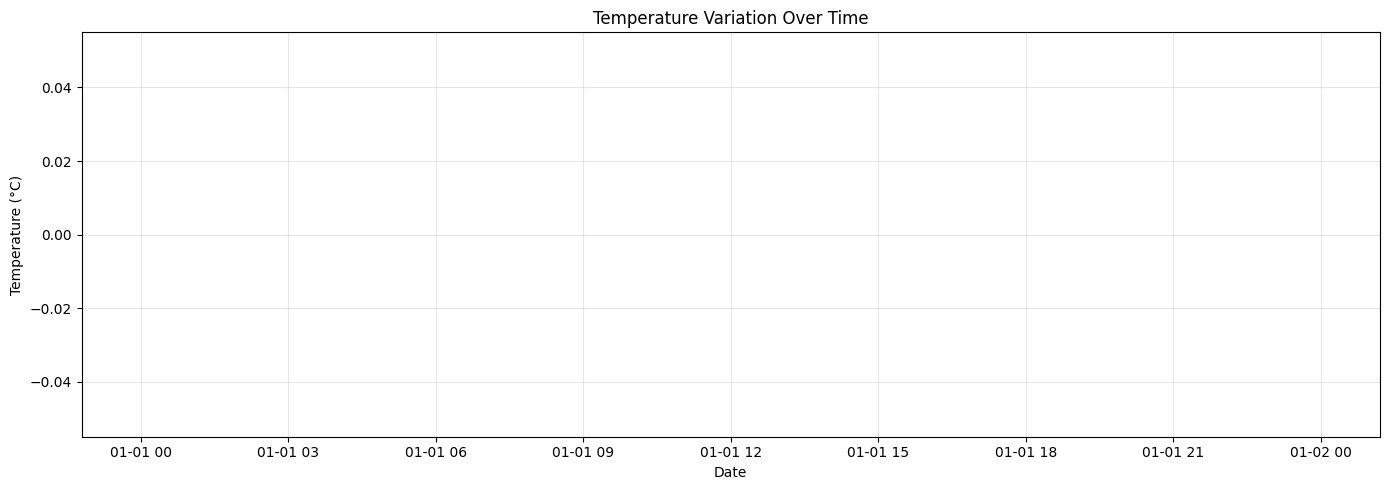

In [26]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["Timestamp"],
    df["T"],
    linewidth=0.8
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Variation Over Time")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
print(df["T"].head(10))
print()
print("Number of valid temperature values:", df["T"].notna().sum())
print("Number of missing temperature values:", df["T"].isna().sum())

Series([], Name: T, dtype: float64)

Number of valid temperature values: 0
Number of missing temperature values: 0


In [28]:
print(df["T"].describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: T, dtype: float64


In [29]:
print(df["Timestamp"].head())
print(df["Timestamp"].dtype)
print(df["Timestamp"].isna().sum())

Series([], Name: Timestamp, dtype: datetime64[ns])
datetime64[ns]
0


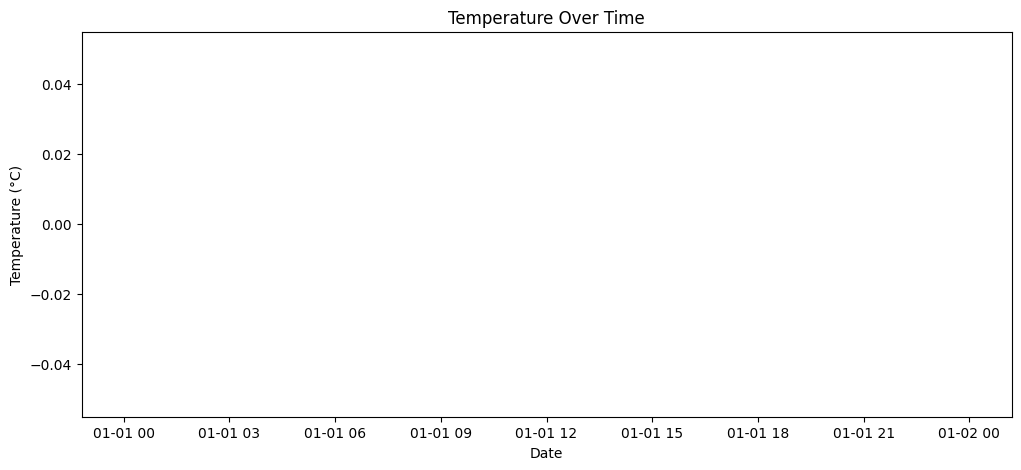

In [30]:
import matplotlib.pyplot as plt

plot_data = df[["Timestamp", "T"]].dropna()

plt.figure(figsize=(12, 5))
plt.plot(plot_data["Timestamp"], plot_data["T"])
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Over Time")
plt.show()

In [31]:
print(plot_data.shape)
print(plot_data.head())

(0, 2)
Empty DataFrame
Columns: [Timestamp, T]
Index: []


In [32]:
print("Rows in df:", len(df))
print("Temperature valid values:", df["T"].notna().sum())
print("Temperature missing values:", df["T"].isna().sum())

print("\nTimestamp valid values:", df["Timestamp"].notna().sum())
print("Timestamp missing values:", df["Timestamp"].isna().sum())

Rows in df: 0
Temperature valid values: 0
Temperature missing values: 0

Timestamp valid values: 0
Timestamp missing values: 0


In [34]:
print(df[["Timestamp", "T"]].head(10))

Empty DataFrame
Columns: [Timestamp, T]
Index: []


In [35]:
df = df.dropna(subset=["Timestamp"])

In [37]:
# Restore the original dataset
df = df_raw.copy()

# Replace -200 with NaN
df = df.replace(-200, np.nan)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 9471
Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [38]:
print(df[["Date", "Time", "T"]].head(10))

         Date      Time     T
0  10/03/2004  18.00.00  13.6
1  10/03/2004  19.00.00  13.3
2  10/03/2004  20.00.00  11.9
3  10/03/2004  21.00.00  11.0
4  10/03/2004  22.00.00  11.2
5  10/03/2004  23.00.00  11.2
6  11/03/2004  00.00.00  11.3
7  11/03/2004  01.00.00  10.7
8  11/03/2004  02.00.00  10.7
9  11/03/2004  03.00.00  10.3


In [39]:
df["Timestamp"] = pd.to_datetime(
    df["Date"].astype(str).str.strip() + " " +
    df["Time"].astype(str).str.strip(),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

print("Valid timestamps:", df["Timestamp"].notna().sum())
print("Invalid timestamps:", df["Timestamp"].isna().sum())

df[["Date", "Time", "Timestamp"]].head(10)

Valid timestamps: 9357
Invalid timestamps: 114


,Date,Time,Timestamp
0,10/03/2004,18.00.00,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2004-03-10 21:00:00
4,10/03/2004,22.00.00,2004-03-10 22:00:00
5,10/03/2004,23.00.00,2004-03-10 23:00:00
6,11/03/2004,00.00.00,2004-03-11 00:00:00
7,11/03/2004,01.00.00,2004-03-11 01:00:00
8,11/03/2004,02.00.00,2004-03-11 02:00:00
9,11/03/2004,03.00.00,2004-03-11 03:00:00


In [40]:
df = df.dropna(subset=["Timestamp"])

df = df.sort_values("Timestamp").reset_index(drop=True)

print("Final rows:", len(df))
print(df[["Timestamp", "T"]].head(10))

Final rows: 9357
            Timestamp     T
0 2004-03-10 18:00:00  13.6
1 2004-03-10 19:00:00  13.3
2 2004-03-10 20:00:00  11.9
3 2004-03-10 21:00:00  11.0
4 2004-03-10 22:00:00  11.2
5 2004-03-10 23:00:00  11.2
6 2004-03-11 00:00:00  11.3
7 2004-03-11 01:00:00  10.7
8 2004-03-11 02:00:00  10.7
9 2004-03-11 03:00:00  10.3


In [41]:
print("Valid temperature values:", df["T"].notna().sum())
print("Missing temperature values:", df["T"].isna().sum())

Valid temperature values: 8991
Missing temperature values: 366


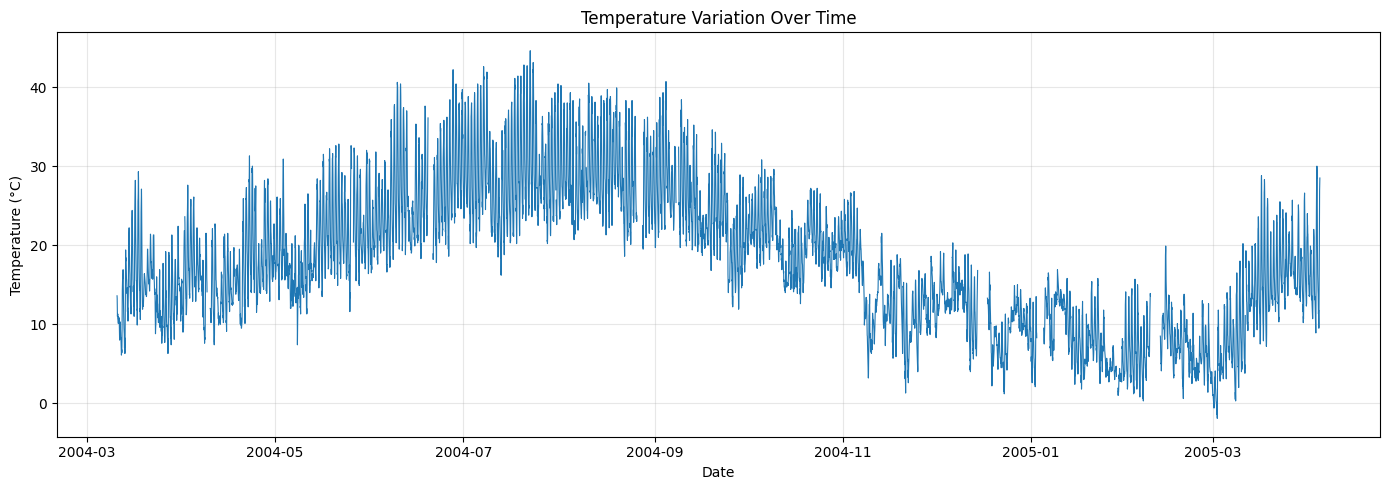

In [42]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["Timestamp"],
    df["T"],
    linewidth=0.8
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Variation Over Time")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
temperature = df["T"].dropna()

print("Temperature Statistics")
print("----------------------")
print("Minimum:", temperature.min())
print("Maximum:", temperature.max())
print("Mean:", temperature.mean())
print("Median:", temperature.median())
print("Standard Deviation:", temperature.std())

Temperature Statistics
----------------------
Minimum: -1.9
Maximum: 44.6
Mean: 18.317828940051164
Median: 17.8
Standard Deviation: 8.832115731829777


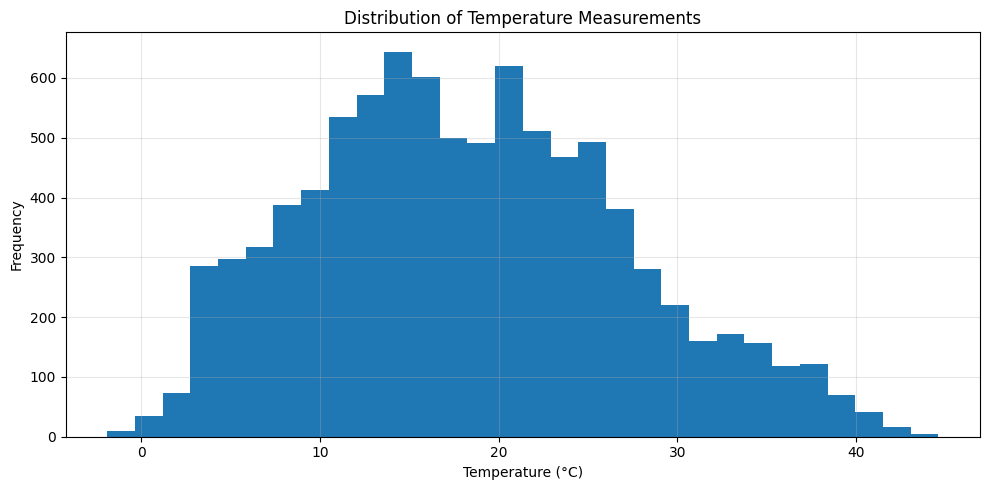

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(temperature, bins=30)

plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Temperature Measurements")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Temperature Anomaly Detection Using IQR

In [45]:
Q1 = temperature.quantile(0.25)
Q3 = temperature.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 11.8
Q3: 24.4
IQR: 12.599999999999998
Lower Bound: -7.099999999999998
Upper Bound: 43.3


In [46]:
df["Temperature_Anomaly"] = (
    (df["T"] < lower_bound) |
    (df["T"] > upper_bound)
)

# Missing temperatures should not be classified as anomalies
df.loc[df["T"].isna(), "Temperature_Anomaly"] = False

print("Total temperature observations:", df["T"].notna().sum())
print("Detected anomalies:", df["Temperature_Anomaly"].sum())

Total temperature observations: 8991
Detected anomalies: 3


In [47]:
anomalies = df[df["Temperature_Anomaly"]]

anomalies[["Timestamp", "T"]].head(20)

,Timestamp,T
3213,2004-07-22 15:00:00,44.3
3214,2004-07-22 16:00:00,44.6
3215,2004-07-22 17:00:00,43.4


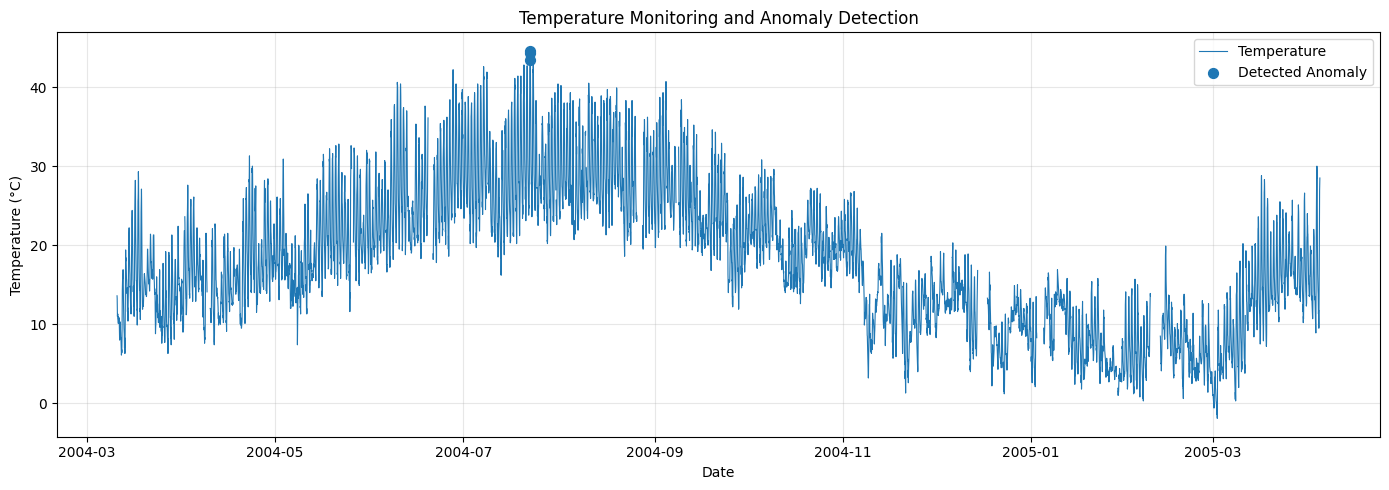

In [48]:
plt.figure(figsize=(14, 5))

# Plot all temperature observations
plt.plot(
    df["Timestamp"],
    df["T"],
    linewidth=0.8,
    label="Temperature"
)

# Plot anomalies
anomaly_data = df[df["Temperature_Anomaly"]]

plt.scatter(
    anomaly_data["Timestamp"],
    anomaly_data["T"],
    s=50,
    label="Detected Anomaly"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Monitoring and Anomaly Detection")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Environmental Conditions During Extreme Temperature

In [49]:
anomaly_period = df[
    (df["Timestamp"] >= "2004-07-22 12:00:00") &
    (df["Timestamp"] <= "2004-07-22 20:00:00")
]

anomaly_period[
    [
        "Timestamp",
        "T",
        "RH",
        "AH",
        "CO(GT)",
        "NOx(GT)",
        "NO2(GT)"
    ]
]

,Timestamp,T,RH,AH,CO(GT),NOx(GT),NO2(GT)
3210,2004-07-22 12:00:00,40.1,19.0,1.3849,2.1,144.0,130.0
3211,2004-07-22 13:00:00,42.0,15.8,1.2759,2.0,117.0,125.0
3212,2004-07-22 14:00:00,42.8,14.3,1.2003,1.5,108.0,113.0
3213,2004-07-22 15:00:00,44.3,13.0,1.1830,2.1,153.0,143.0
3214,2004-07-22 16:00:00,44.6,12.6,1.1684,2.3,166.0,157.0
3215,2004-07-22 17:00:00,43.4,14.8,1.2882,2.8,179.0,170.0
3216,2004-07-22 18:00:00,40.6,18.2,1.3680,3.6,225.0,187.0
3217,2004-07-22 19:00:00,37.1,21.3,1.3223,4.0,261.0,181.0
3218,2004-07-22 20:00:00,34.5,25.5,1.3680,3.7,228.0,158.0


In [50]:
normal_data = df[~df["Temperature_Anomaly"]]

comparison = pd.DataFrame({
    "Normal Period": normal_data[
        ["T", "RH", "AH", "CO(GT)", "NOx(GT)", "NO2(GT)"]
    ].mean(),

    "Anomaly Period": anomaly_period[
        ["T", "RH", "AH", "CO(GT)", "NOx(GT)", "NO2(GT)"]
    ].mean()
})

comparison

,Normal Period,Anomaly Period
T,18.309223,41.044444
RH,49.246139,17.166667
AH,1.025468,1.284333
CO(GT),2.152653,2.677778
NOx(GT),246.928192,175.666667
NO2(GT),113.074300,151.555556


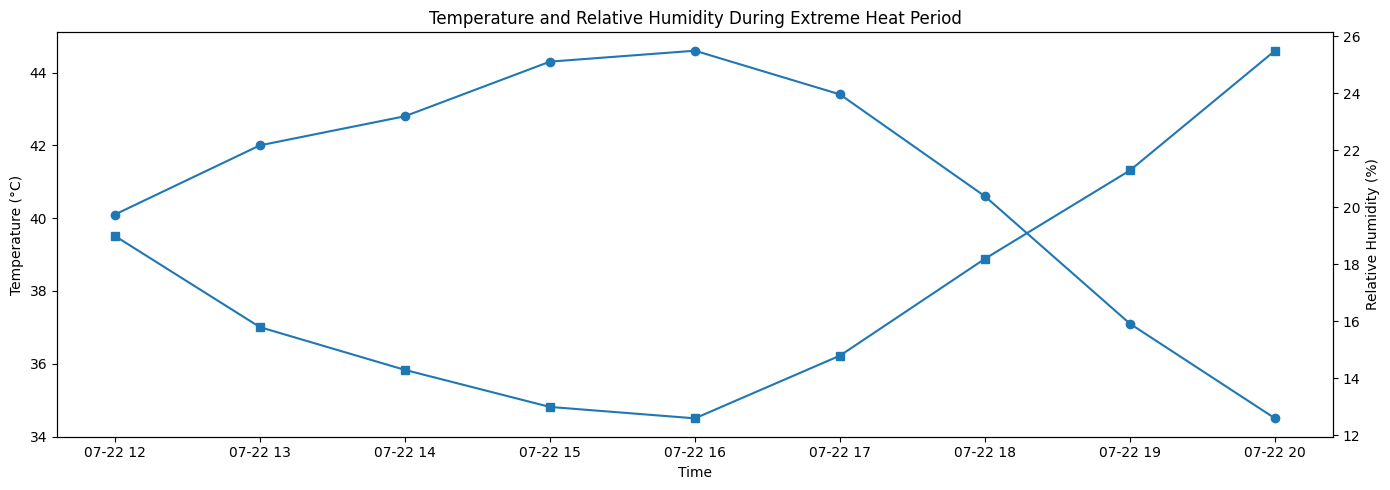

In [51]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Temperature
ax1.plot(
    anomaly_period["Timestamp"],
    anomaly_period["T"],
    marker="o",
    label="Temperature (°C)"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)")

# Relative humidity
ax2 = ax1.twinx()

ax2.plot(
    anomaly_period["Timestamp"],
    anomaly_period["RH"],
    marker="s",
    label="Relative Humidity (%)"
)

ax2.set_ylabel("Relative Humidity (%)")

plt.title("Temperature and Relative Humidity During Extreme Heat Period")
plt.tight_layout()
plt.show()

In [52]:
features = [
    "T",
    "RH",
    "AH",
    "CO(GT)",
    "NO2(GT)"
]

ml_data = df[features].dropna().copy()

print("Rows available for ML:", len(ml_data))
print("\nFeatures:")
print(ml_data.columns.tolist())

ml_data.head()

Rows available for ML: 6941

Features:
['T', 'RH', 'AH', 'CO(GT)', 'NO2(GT)']


,T,RH,AH,CO(GT),NO2(GT)
0,13.6,48.9,0.7578,2.6,113.0
1,13.3,47.7,0.7255,2.0,92.0
2,11.9,54.0,0.7502,2.2,114.0
3,11.0,60.0,0.7867,2.2,122.0
4,11.2,59.6,0.7888,1.6,116.0


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(ml_data)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (6941, 5)


## 6. Multivariate Anomaly Detection Using Isolation Forest

In [54]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.01,
    random_state=42
)

ml_predictions = model.fit_predict(X_scaled)

ml_data["ML_Anomaly"] = ml_predictions == -1

print("Total observations:", len(ml_data))
print("ML anomalies:", ml_data["ML_Anomaly"].sum())

Total observations: 6941
ML anomalies: 70


In [55]:
ml_anomalies = ml_data[ml_data["ML_Anomaly"]]

ml_anomalies.head(20)

,T,RH,AH,CO(GT),NO2(GT),ML_Anomaly
2184,37.3,23.4,1.4672,4.9,222.0,True
2208,35.8,22.1,1.2792,4.8,206.0,True
2665,34.7,31.9,1.7325,4.6,202.0,True
2687,38.8,24.2,1.6433,4.2,226.0,True
2688,33.5,38.0,1.9390,4.9,207.0,True
2831,39.5,12.6,0.8894,3.8,192.0,True
2832,37.9,13.9,0.9015,4.4,194.0,True
2856,36.9,17.9,1.0960,4.3,233.0,True
2857,35.6,20.4,1.1646,5.3,223.0,True
2881,34.9,29.3,1.6110,5.1,206.0,True


In [56]:
print("Total ML observations:", len(ml_data))
print("ML anomalies:", ml_data["ML_Anomaly"].sum())

anomaly_percentage = (
    ml_data["ML_Anomaly"].sum() / len(ml_data)
) * 100

print("Anomaly percentage:", round(anomaly_percentage, 2), "%")

Total ML observations: 6941
ML anomalies: 70
Anomaly percentage: 1.01 %


In [57]:
contamination=0.01

In [58]:
# Number of anomalies detected by each method
iqr_anomalies = df["Temperature_Anomaly"].sum()
ml_anomalies = ml_data["ML_Anomaly"].sum()

# Create comparison table
comparison_methods = pd.DataFrame({
    "Method": [
        "IQR (Temperature)",
        "Isolation Forest (Multivariate)"
    ],
    "Variables Used": [
        "Temperature only",
        "Temperature, RH, AH, CO, NO2"
    ],
    "Anomalies Detected": [
        iqr_anomalies,
        ml_anomalies
    ]
})

comparison_methods

,Method,Variables Used,Anomalies Detected
0,IQR (Temperature),Temperature only,3
1,Isolation Forest (Multivariate),"Temperature, RH, AH, CO, NO2",70


In [59]:
# Add Timestamp to the ML dataset using its original index
ml_data["Timestamp"] = df.loc[ml_data.index, "Timestamp"]

# Select the detected anomalies
ml_anomalies = ml_data[ml_data["ML_Anomaly"]].copy()

# Display the anomalies with their timestamps
ml_anomalies[
    [
        "Timestamp",
        "T",
        "RH",
        "AH",
        "CO(GT)",
        "NO2(GT)",
        "ML_Anomaly"
    ]
].head(20)

,Timestamp,T,RH,AH,CO(GT),NO2(GT),ML_Anomaly
2184,2004-06-09 18:00:00,37.3,23.4,1.4672,4.9,222.0,True
2208,2004-06-10 18:00:00,35.8,22.1,1.2792,4.8,206.0,True
2665,2004-06-29 19:00:00,34.7,31.9,1.7325,4.6,202.0,True
2687,2004-06-30 17:00:00,38.8,24.2,1.6433,4.2,226.0,True
2688,2004-06-30 18:00:00,33.5,38.0,1.9390,4.9,207.0,True
2831,2004-07-06 17:00:00,39.5,12.6,0.8894,3.8,192.0,True
2832,2004-07-06 18:00:00,37.9,13.9,0.9015,4.4,194.0,True
2856,2004-07-07 18:00:00,36.9,17.9,1.0960,4.3,233.0,True
2857,2004-07-07 19:00:00,35.6,20.4,1.1646,5.3,223.0,True
2881,2004-07-08 19:00:00,34.9,29.3,1.6110,5.1,206.0,True


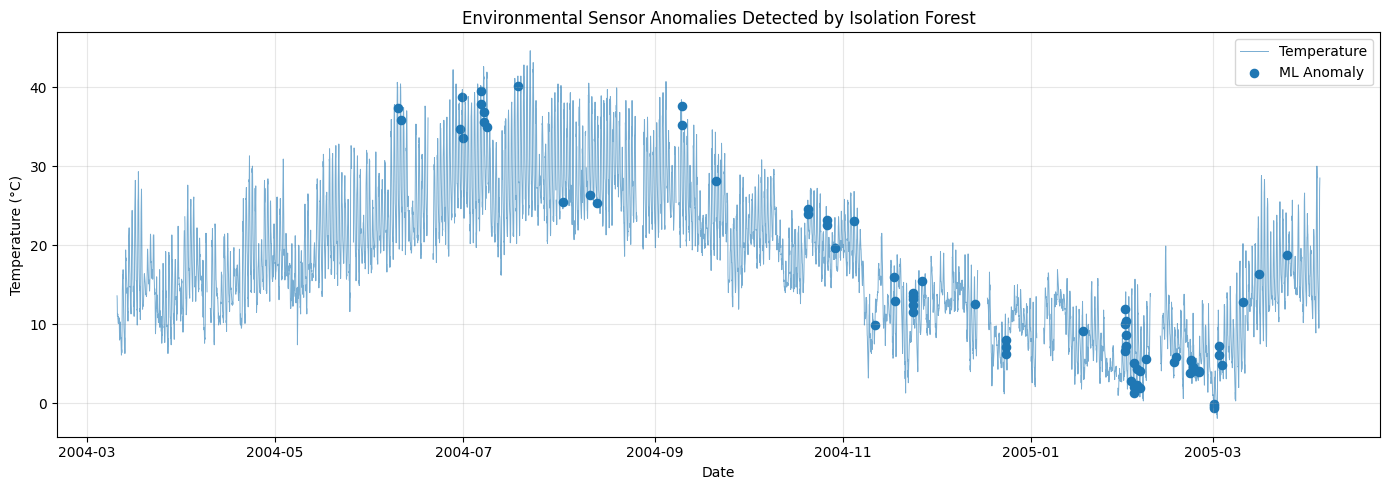

In [60]:
plt.figure(figsize=(14, 5))

# Plot all temperature observations
plt.plot(
    df["Timestamp"],
    df["T"],
    linewidth=0.7,
    alpha=0.6,
    label="Temperature"
)

# Plot ML anomalies
plt.scatter(
    ml_anomalies["Timestamp"],
    ml_anomalies["T"],
    s=35,
    label="ML Anomaly"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Environmental Sensor Anomalies Detected by Isolation Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Normal vs. Anomalous Environmental Conditions

In [61]:
# Separate normal and anomalous observations
normal_ml = ml_data[~ml_data["ML_Anomaly"]]
anomaly_ml = ml_data[ml_data["ML_Anomaly"]]

# Variables we want to compare
variables = ["T", "RH", "AH", "CO(GT)", "NO2(GT)"]

# Calculate averages
comparison = pd.DataFrame({
    "Normal Mean": normal_ml[variables].mean(),
    "Anomaly Mean": anomaly_ml[variables].mean()
})

# Calculate percentage difference
comparison["Difference (%)"] = (
    (comparison["Anomaly Mean"] - comparison["Normal Mean"])
    / comparison["Normal Mean"]
) * 100

comparison.round(2)

,Normal Mean,Anomaly Mean,Difference (%)
T,17.78,15.35,-13.66
RH,48.87,49.57,1.42
AH,0.99,0.89,-10.13
CO(GT),2.15,5.41,151.68
NO2(GT),112.78,221.10,96.04


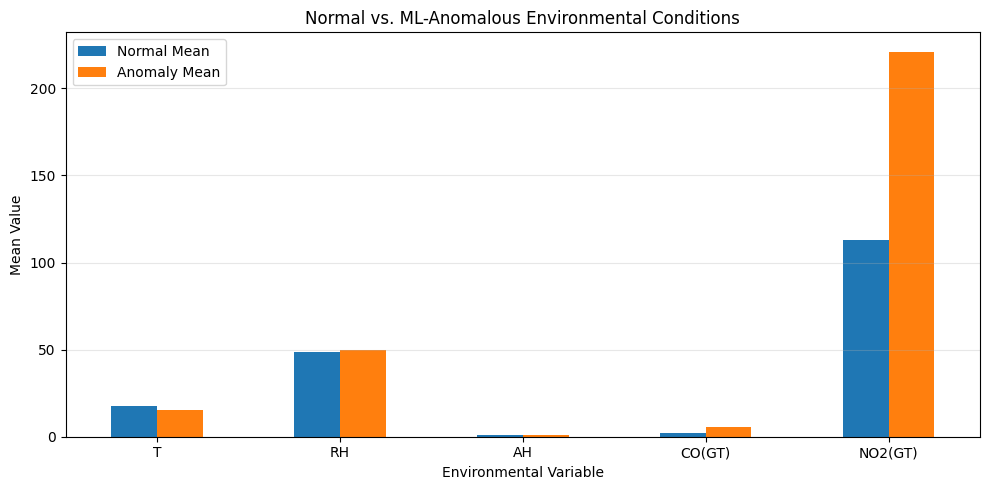

In [62]:
comparison[["Normal Mean", "Anomaly Mean"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Environmental Variable")
plt.ylabel("Mean Value")
plt.title("Normal vs. ML-Anomalous Environmental Conditions")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
variables = ["T", "RH", "AH", "CO(GT)", "NO2(GT)"]

# Standardize the original observations
scaler = StandardScaler()

normal_scaled = scaler.fit_transform(normal_ml[variables])
anomaly_scaled = scaler.transform(anomaly_ml[variables])

# Calculate the mean standardized value
standardized_comparison = pd.DataFrame({
    "Normal": normal_scaled.mean(axis=0),
    "ML Anomaly": anomaly_scaled.mean(axis=0)
}, index=variables)

standardized_comparison

,Normal,ML Anomaly
T,-1.323672e-16,-0.276044
RH,-1.323672e-16,0.039821
AH,1.323672e-16,-0.250156
CO(GT),7.445652e-17,2.356524
NO2(GT),3.309179e-17,2.363180


## 8. Standardized Feature Comparison

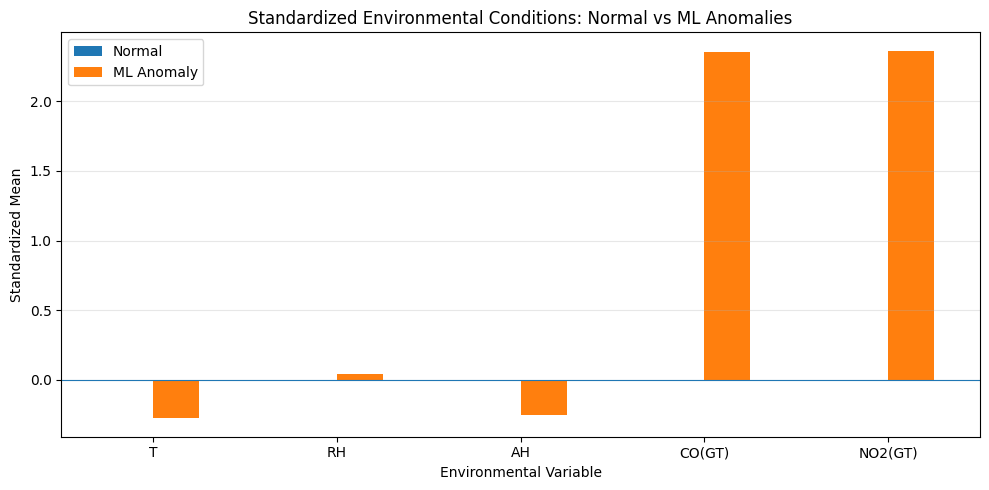

In [65]:
standardized_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Environmental Variable")
plt.ylabel("Standardized Mean")
plt.title("Standardized Environmental Conditions: Normal vs ML Anomalies")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
final_data = df[
    [
        "Timestamp",
        "T",
        "RH",
        "AH",
        "CO(GT)",
        "NO2(GT)",
        "Temperature_Anomaly"
    ]
].copy()

# Add the ML anomaly labels
final_data["ML_Anomaly"] = False

final_data.loc[
    ml_anomalies.index,
    "ML_Anomaly"
] = True

print("Final dataset shape:", final_data.shape)

final_data.head()

Final dataset shape: (9357, 8)


,Timestamp,T,RH,AH,CO(GT),NO2(GT),Temperature_Anomaly,ML_Anomaly
0,2004-03-10 18:00:00,13.6,48.9,0.7578,2.6,113.0,False,False
1,2004-03-10 19:00:00,13.3,47.7,0.7255,2.0,92.0,False,False
2,2004-03-10 20:00:00,11.9,54.0,0.7502,2.2,114.0,False,False
3,2004-03-10 21:00:00,11.0,60.0,0.7867,2.2,122.0,False,False
4,2004-03-10 22:00:00,11.2,59.6,0.7888,1.6,116.0,False,False


In [67]:
print("Temperature anomalies:", final_data["Temperature_Anomaly"].sum())
print("ML anomalies:", final_data["ML_Anomaly"].sum())

print("\nBoth methods flagged:")
print(
    (
        final_data["Temperature_Anomaly"] &
        final_data["ML_Anomaly"]
    ).sum()
)

Temperature anomalies: 3
ML anomalies: 70

Both methods flagged:
0


## 9. Final Anomaly Dataset

In [68]:
final_data.to_csv(
    "environmental_sensor_anomalies.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [69]:
import os

print(os.path.getsize("environmental_sensor_anomalies.csv"), "bytes")

527775 bytes


In [70]:
anomaly_records = final_data[
    (final_data["Temperature_Anomaly"]) |
    (final_data["ML_Anomaly"])
].copy()

print("Total anomaly records:", len(anomaly_records))

anomaly_records.head(20)

Total anomaly records: 73


,Timestamp,T,RH,AH,CO(GT),NO2(GT),Temperature_Anomaly,ML_Anomaly
2184,2004-06-09 18:00:00,37.3,23.4,1.4672,4.9,222.0,False,True
2208,2004-06-10 18:00:00,35.8,22.1,1.2792,4.8,206.0,False,True
2665,2004-06-29 19:00:00,34.7,31.9,1.7325,4.6,202.0,False,True
2687,2004-06-30 17:00:00,38.8,24.2,1.6433,4.2,226.0,False,True
2688,2004-06-30 18:00:00,33.5,38.0,1.9390,4.9,207.0,False,True
2831,2004-07-06 17:00:00,39.5,12.6,0.8894,3.8,192.0,False,True
2832,2004-07-06 18:00:00,37.9,13.9,0.9015,4.4,194.0,False,True
2856,2004-07-07 18:00:00,36.9,17.9,1.0960,4.3,233.0,False,True
2857,2004-07-07 19:00:00,35.6,20.4,1.1646,5.3,223.0,False,True
2881,2004-07-08 19:00:00,34.9,29.3,1.6110,5.1,206.0,False,True


In [71]:
anomaly_records[
    ["Timestamp", "T", "RH", "AH", "CO(GT)", "NO2(GT)",
     "Temperature_Anomaly", "ML_Anomaly"]
]

,Timestamp,T,RH,AH,CO(GT),NO2(GT),Temperature_Anomaly,ML_Anomaly
2184,2004-06-09 18:00:00,37.3,23.4,1.4672,4.9,222.0,False,True
2208,2004-06-10 18:00:00,35.8,22.1,1.2792,4.8,206.0,False,True
2665,2004-06-29 19:00:00,34.7,31.9,1.7325,4.6,202.0,False,True
2687,2004-06-30 17:00:00,38.8,24.2,1.6433,4.2,226.0,False,True
2688,2004-06-30 18:00:00,33.5,38.0,1.9390,4.9,207.0,False,True
...,...,...,...,...,...,...,...,...
8570,2005-03-02 20:00:00,6.1,34.0,0.3237,5.3,236.0,False,True
8593,2005-03-03 19:00:00,4.9,82.4,0.7201,5.4,228.0,False,True
8762,2005-03-10 20:00:00,12.8,22.8,0.3364,5.4,245.0,False,True
8882,2005-03-15 20:00:00,16.4,41.9,0.7759,7.4,248.0,False,True


In [72]:
anomaly_summary = pd.DataFrame({
    "Category": [
        "Temperature-only anomalies",
        "Multivariate ML anomalies",
        "Both methods",
        "Total unique anomalies"
    ],
    "Count": [
        final_data["Temperature_Anomaly"].sum(),
        final_data["ML_Anomaly"].sum(),
        (
            final_data["Temperature_Anomaly"] &
            final_data["ML_Anomaly"]
        ).sum(),
        len(anomaly_records)
    ]
})

anomaly_summary

,Category,Count
0,Temperature-only anomalies,3
1,Multivariate ML anomalies,70
2,Both methods,0
3,Total unique anomalies,73


## 10. Anomaly Results and Visualization

In [73]:
anomaly_summary["Percentage of Dataset"] = (
    anomaly_summary["Count"] / len(final_data) * 100
).round(2)

anomaly_summary

,Category,Count,Percentage of Dataset
0,Temperature-only anomalies,3,0.03
1,Multivariate ML anomalies,70,0.75
2,Both methods,0,0.00
3,Total unique anomalies,73,0.78


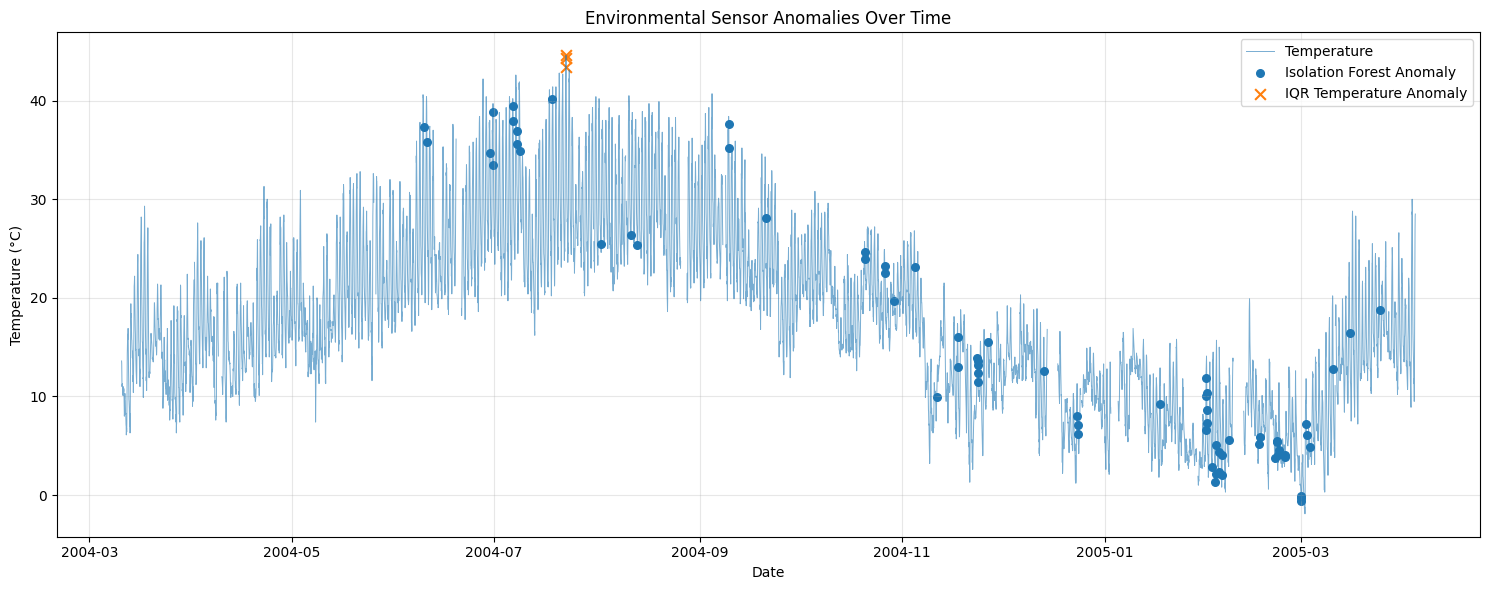

In [74]:
plt.figure(figsize=(15, 6))

# Temperature observations
plt.plot(
    final_data["Timestamp"],
    final_data["T"],
    linewidth=0.7,
    alpha=0.6,
    label="Temperature"
)

# ML anomalies
ml_points = final_data[final_data["ML_Anomaly"]]

plt.scatter(
    ml_points["Timestamp"],
    ml_points["T"],
    s=30,
    label="Isolation Forest Anomaly"
)

# IQR temperature anomalies
iqr_points = final_data[final_data["Temperature_Anomaly"]]

plt.scatter(
    iqr_points["Timestamp"],
    iqr_points["T"],
    s=60,
    marker="x",
    label="IQR Temperature Anomaly"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Environmental Sensor Anomalies Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

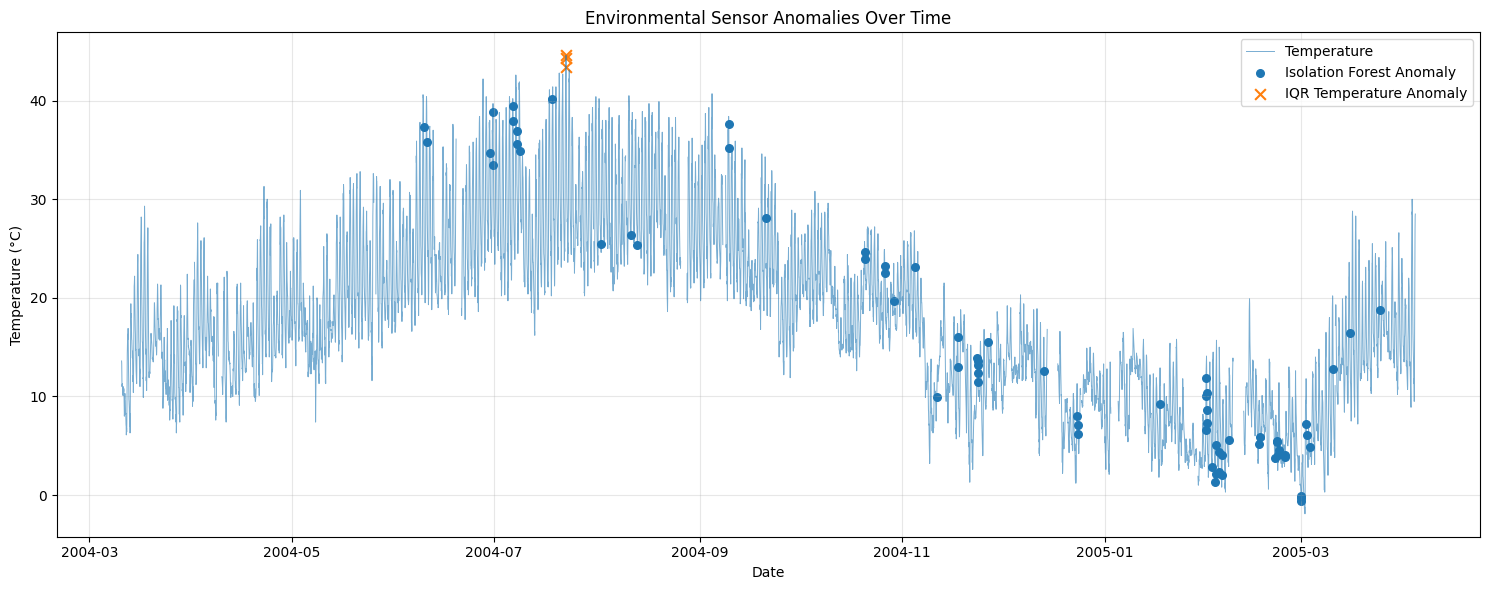

Figure saved successfully!


In [75]:
plt.figure(figsize=(15, 6))

plt.plot(
    final_data["Timestamp"],
    final_data["T"],
    linewidth=0.7,
    alpha=0.6,
    label="Temperature"
)

ml_points = final_data[final_data["ML_Anomaly"]]

plt.scatter(
    ml_points["Timestamp"],
    ml_points["T"],
    s=30,
    label="Isolation Forest Anomaly"
)

iqr_points = final_data[final_data["Temperature_Anomaly"]]

plt.scatter(
    iqr_points["Timestamp"],
    iqr_points["T"],
    s=60,
    marker="x",
    label="IQR Temperature Anomaly"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Environmental Sensor Anomalies Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "environmental_sensor_anomalies_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully!")

In [76]:
project_results = pd.DataFrame({
    "Metric": [
        "Total observations",
        "Temperature observations",
        "Temperature IQR anomalies",
        "Isolation Forest anomalies",
        "Total unique anomalies",
        "Percentage of observations flagged"
    ],
    "Value": [
        len(final_data),
        final_data["T"].notna().sum(),
        final_data["Temperature_Anomaly"].sum(),
        final_data["ML_Anomaly"].sum(),
        len(anomaly_records),
        round(len(anomaly_records) / len(final_data) * 100, 2)
    ]
})

project_results

,Metric,Value
0,Total observations,9357.00
1,Temperature observations,8991.00
2,Temperature IQR anomalies,3.00
3,Isolation Forest anomalies,70.00
4,Total unique anomalies,73.00
5,Percentage of observations flagged,0.78


In [77]:
final_data.isna().sum()

,0
Timestamp,0
T,366
RH,366
AH,366
CO(GT),1683
NO2(GT),1642
Temperature_Anomaly,0
ML_Anomaly,0


In [78]:
print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))
print("Duplicate timestamps:", final_data["Timestamp"].duplicated().sum())

Rows: 9357
Columns: 8
Duplicate timestamps: 0


## 11. Data Quality Assessment

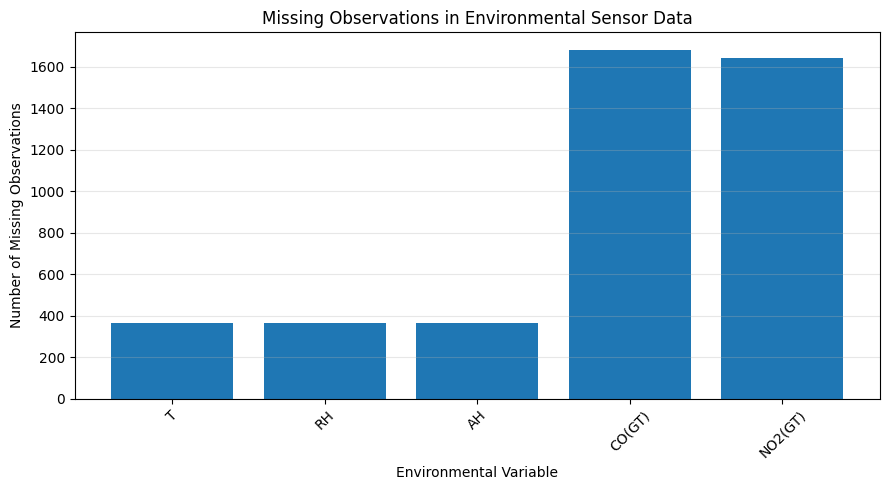

In [79]:
missing_counts = final_data.isna().sum()

missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(9, 5))

plt.bar(
    missing_counts.index,
    missing_counts.values
)

plt.xlabel("Environmental Variable")
plt.ylabel("Number of Missing Observations")
plt.title("Missing Observations in Environmental Sensor Data")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

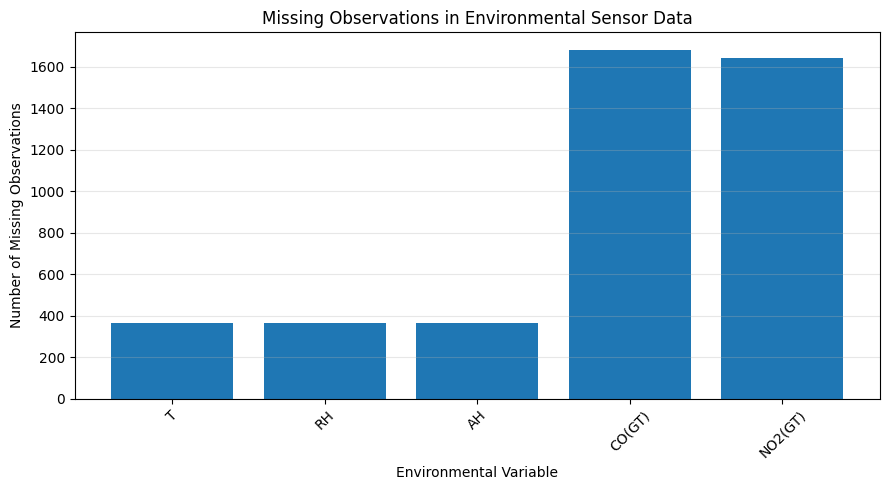

Missing-data figure saved successfully!


In [80]:
missing_counts = final_data.isna().sum()
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(9, 5))

plt.bar(
    missing_counts.index,
    missing_counts.values
)

plt.xlabel("Environmental Variable")
plt.ylabel("Number of Missing Observations")
plt.title("Missing Observations in Environmental Sensor Data")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "missing_data_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Missing-data figure saved successfully!")

In [81]:
variables = ["T", "RH", "AH", "CO(GT)", "NO2(GT)"]

normal_means = normal_ml[variables].mean()

anomaly_pattern = pd.DataFrame({
    "Normal Mean": normal_means,
    "ML Anomaly Mean": anomaly_ml[variables].mean()
})

anomaly_pattern["Anomaly / Normal Ratio"] = (
    anomaly_pattern["ML Anomaly Mean"] /
    anomaly_pattern["Normal Mean"]
).round(2)

anomaly_pattern

,Normal Mean,ML Anomaly Mean,Anomaly / Normal Ratio
T,17.779814,15.351429,0.86
RH,48.874924,49.567143,1.01
AH,0.986580,0.886663,0.90
CO(GT),2.149585,5.410000,2.52
NO2(GT),112.781691,221.100000,1.96


In [82]:
anomaly_pattern.sort_values(
    "Anomaly / Normal Ratio",
    ascending=False
)

,Normal Mean,ML Anomaly Mean,Anomaly / Normal Ratio
CO(GT),2.149585,5.410000,2.52
NO2(GT),112.781691,221.100000,1.96
RH,48.874924,49.567143,1.01
AH,0.986580,0.886663,0.90
T,17.779814,15.351429,0.86


## 12. Environmental Pattern Analysis

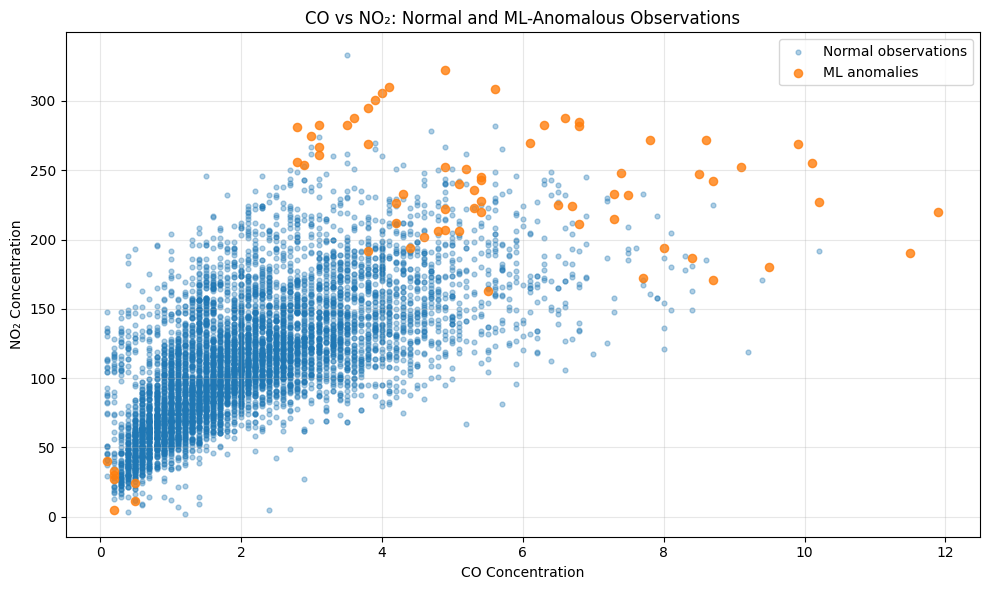

In [83]:
plt.figure(figsize=(10, 6))

plt.scatter(
    normal_ml["CO(GT)"],
    normal_ml["NO2(GT)"],
    s=12,
    alpha=0.35,
    label="Normal observations"
)

plt.scatter(
    anomaly_ml["CO(GT)"],
    anomaly_ml["NO2(GT)"],
    s=35,
    alpha=0.8,
    label="ML anomalies"
)

plt.xlabel("CO Concentration")
plt.ylabel("NO₂ Concentration")
plt.title("CO vs NO₂: Normal and ML-Anomalous Observations")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
import os

project_folder = "Environmental_Sensor_Monitoring"

os.makedirs(project_folder, exist_ok=True)

print("Project folder created:", project_folder)

Project folder created: Environmental_Sensor_Monitoring


In [85]:
import shutil

files_to_copy = [
    "environmental_sensor_anomalies.csv",
    "environmental_sensor_anomalies_timeline.png",
    "missing_data_overview.png"
]

for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, project_folder)
        print("Copied:", file)
    else:
        print("Not found:", file)

Copied: environmental_sensor_anomalies.csv
Copied: environmental_sensor_anomalies_timeline.png
Copied: missing_data_overview.png


In [86]:
print(os.listdir(project_folder))

['missing_data_overview.png', 'environmental_sensor_anomalies.csv', 'environmental_sensor_anomalies_timeline.png']


In [87]:
import os

print(os.listdir("/content")[:30])

['.config', 'missing_data_overview.png', 'environmental_sensor_anomalies.csv', 'environmental_sensor_anomalies_timeline.png', 'Environmental_Sensor_Monitoring', 'sample_data']


In [88]:
import shutil
import os

notebook_path = "/content/Environmental_Sensor_Monitoring.ipynb"
destination = "/content/Environmental_Sensor_Monitoring/Environmental_Sensor_Monitoring.ipynb"

if os.path.exists(notebook_path):
    shutil.copy(notebook_path, destination)
    print("Notebook copied successfully!")
else:
    print("Notebook file not found yet.")

Notebook file not found yet.


In [89]:
readme_content = """
# Environmental Sensor Monitoring & Anomaly Detection

## Project Overview

This project analyzes real-world environmental sensor data to identify unusual environmental conditions using statistical and machine-learning-based anomaly detection methods.

The project combines environmental data analysis, statistical methods, and unsupervised machine learning to investigate anomalies in air-quality and meteorological sensor observations.

## Objectives

- Clean and preprocess environmental sensor data.
- Handle missing and invalid sensor observations.
- Analyze environmental variables over time.
- Detect extreme temperature observations using the Interquartile Range (IQR) method.
- Detect multivariate anomalies using Isolation Forest.
- Compare normal and anomalous environmental conditions.
- Visualize detected anomalies and data-quality patterns.

## Dataset

Dataset: UCI Air Quality Dataset

The dataset contains approximately one year of hourly environmental sensor observations collected in an urban area.

Selected variables used in this project include:

- Temperature (T)
- Relative Humidity (RH)
- Absolute Humidity (AH)
- Carbon Monoxide (CO)
- Nitrogen Dioxide (NO2)

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab

## Methodology

### 1. Data Preprocessing

The dataset was loaded and cleaned using Pandas.

Key preprocessing steps included:

- Removing empty columns.
- Converting the UCI missing-value indicator (-200) to NaN.
- Combining Date and Time into a Timestamp variable.
- Removing records with invalid timestamps.
- Sorting observations chronologically.

### 2. Temperature Anomaly Detection

The Interquartile Range (IQR) method was applied to temperature observations.

The anomaly boundaries were calculated as:

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

This method identified 3 extreme temperature observations.

### 3. Multivariate Anomaly Detection

Isolation Forest was applied to five environmental variables:

- Temperature
- Relative Humidity
- Absolute Humidity
- CO
- NO2

The selected variables were standardized before applying the model.

The Isolation Forest identified 70 multivariate anomalies among the complete observations used for model training.

## Key Results

| Metric | Result |
|---|---:|
| Total observations | 9,357 |
| Temperature observations | 8,991 |
| Temperature IQR anomalies | 3 |
| Isolation Forest anomalies | 70 |
| Total unique anomalies | 73 |
| Percentage flagged | 0.78% |

The IQR method and Isolation Forest identified different observations, with no overlap between the two methods.

The multivariate anomaly group showed notable differences in CO and NO2 compared with normal observations:

- CO mean: 2.15 → 5.41
- NO2 mean: 112.78 → 221.10

These differences represent associations observed in the dataset and should not be interpreted as evidence of causation.

## Data Quality

The final dataset contains:

- 0 missing timestamps
- 0 duplicate timestamps
- 366 missing temperature observations
- 366 missing relative humidity observations
- 366 missing absolute humidity observations
- 1,683 missing CO observations
- 1,642 missing NO2 observations

Missing values were retained in the final dataset rather than being artificially imputed.

## Visualizations

The project includes:

1. Environmental sensor anomaly timeline
2. Missing-data overview
3. CO vs NO2 distribution of normal and ML-anomalous observations
4. Temperature variation over time
5. Normal vs anomalous environmental conditions

## Limitations

- Isolation Forest is an unsupervised anomaly-detection method and does not establish whether an observation represents a true environmental event.
- The selected contamination parameter affects the number of anomalies detected.
- Missing observations reduce the number of records available for multivariate ML analysis.
- The dataset represents a specific monitoring location and time period, so results should not automatically be generalized to other locations.
- The analysis identifies statistical patterns rather than causal relationships.

## Future Improvements

Potential extensions include:

- Testing additional anomaly-detection algorithms such as Local Outlier Factor and One-Class SVM.
- Incorporating additional pollutant and sensor variables.
- Using time-series models for temporal anomaly detection.
- Building an interactive Streamlit dashboard.
- Adding geospatial environmental datasets.
- Integrating satellite-derived environmental indicators.
- Developing real-time environmental sensor monitoring capabilities.

## Project Skills Demonstrated

This project demonstrates practical skills in:

- Environmental data analysis
- Data cleaning and preprocessing
- Statistical anomaly detection
- Unsupervised machine learning
- Feature standardization
- Exploratory data analysis
- Environmental sensor data interpretation
- Python programming
- Data visualization
"""

In [90]:
readme_path = "/content/Environmental_Sensor_Monitoring/README.md"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [91]:
with open(readme_path, "r", encoding="utf-8") as f:
    print(f.read()[:2000])


# Environmental Sensor Monitoring & Anomaly Detection

## Project Overview

This project analyzes real-world environmental sensor data to identify unusual environmental conditions using statistical and machine-learning-based anomaly detection methods.

The project combines environmental data analysis, statistical methods, and unsupervised machine learning to investigate anomalies in air-quality and meteorological sensor observations.

## Objectives

- Clean and preprocess environmental sensor data.
- Handle missing and invalid sensor observations.
- Analyze environmental variables over time.
- Detect extreme temperature observations using the Interquartile Range (IQR) method.
- Detect multivariate anomalies using Isolation Forest.
- Compare normal and anomalous environmental conditions.
- Visualize detected anomalies and data-quality patterns.

## Dataset

Dataset: UCI Air Quality Dataset

The dataset contains approximately one year of hourly environmental sensor observations collecte

In [92]:
requirements = """pandas
numpy
matplotlib
scikit-learn
requests
"""

requirements_path = "/content/Environmental_Sensor_Monitoring/requirements.txt"

with open(requirements_path, "w", encoding="utf-8") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [93]:
with open(requirements_path, "r", encoding="utf-8") as f:
    print(f.read())

pandas
numpy
matplotlib
scikit-learn
requests



In [94]:
project_results_clean = pd.DataFrame({
    "Metric": [
        "Total observations",
        "Temperature observations",
        "Temperature IQR anomalies",
        "Isolation Forest anomalies",
        "Total unique anomalies",
        "Percentage of observations flagged"
    ],
    "Value": [
        int(len(final_data)),
        int(final_data["T"].notna().sum()),
        int(final_data["Temperature_Anomaly"].sum()),
        int(final_data["ML_Anomaly"].sum()),
        int(len(anomaly_records)),
        round(len(anomaly_records) / len(final_data) * 100, 2)
    ]
})

results_path = (
    "/content/Environmental_Sensor_Monitoring/"
    "project_results.csv"
)

project_results_clean.to_csv(
    results_path,
    index=False
)

print("project_results.csv created successfully!")

project_results.csv created successfully!


In [95]:
project_results_clean

,Metric,Value
0,Total observations,9357.00
1,Temperature observations,8991.00
2,Temperature IQR anomalies,3.00
3,Isolation Forest anomalies,70.00
4,Total unique anomalies,73.00
5,Percentage of observations flagged,0.78


## Conclusion

This project demonstrated an end-to-end workflow for environmental sensor anomaly detection using statistical and machine-learning methods.

The IQR method identified three extreme temperature observations, while Isolation Forest detected 70 multivariate anomalies among the complete observations used for modeling. In total, 73 unique observations were flagged.

The analysis also showed that the ML-anomalous group had substantially different mean CO and NO₂ values compared with the normal group. These findings represent statistical associations within the dataset and should not be interpreted as causal relationships.

The project demonstrates practical skills in environmental data preprocessing, exploratory analysis, statistical anomaly detection, unsupervised machine learning, visualization, and interpretation of environmental sensor data.

In [96]:
import shutil

project_folder = "/content/Environmental_Sensor_Monitoring"

zip_path = shutil.make_archive(
    "/content/Environmental_Sensor_Monitoring",
    "zip",
    project_folder
)

print("ZIP created successfully!")
print(zip_path)

ZIP created successfully!
/content/Environmental_Sensor_Monitoring.zip


In [97]:
from google.colab import files

files.download(
    "/content/Environmental_Sensor_Monitoring.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>